# Vessel ETA Prediction using Prior-Guided Temporal Learning

This notebook provides the teaching code for Chapter 12. It demonstrates how to construct AIS-based samples, extract temporal and static representations, incorporate prior-guided voyage features, train an MLP regression head, and visualize predicted versus true ETA values.

The code logic is kept unchanged from the original implementation. Only explanatory Markdown cells and English comments are added, and repeated imports are consolidated into the setup cell.


## 1. Environment setup and data loading

The first cell imports the required Python libraries and loads the prepared dataset. The dataset is assumed to contain AIS trajectory variables, vessel static attributes, prior-guided features, and the ETA target.


In [1]:
# =========================================================
# Chapter 12: ETA Prediction using Prior-Guided Temporal Learning
# Basic environment setup and data loading
# =========================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the prepared AIS-based ETA dataset.
df = pd.read_csv('ETA_data.csv')


## 2. Feature construction and model training

This section defines three groups of inputs: sequential trajectory features, static vessel attributes, and direct prior-guided features. A sliding window is used to construct historical trajectory sequences. The LSTM encoder and static encoder produce latent representations, which are then concatenated with prior-guided features for ETA regression.


In [2]:
# =========================================================
# ETA Prediction Pipeline
# LSTM + Static Encoder (Frozen) + MLP Regression Head
# Save model with minimum TEST MAE
# =========================================================


# =========================
# Feature definitions
# =========================
# Sequential features contain AIS states and matched environmental variables.
# Static features describe vessel particulars.
# Direct features provide prior-guided voyage information.
SEQ_COLS = [
    "Lat", "Lng",
    "Speed over ground", "Course over ground",
    "wind_speed", "wind_direction",
    "wave_hs", "wave_direction", "wave_period",
    "current_speed", "current_direction"
]

STATIC_COLS = ["LENGTH ", "BREATH", "DEPTH", "DRAUGHT", "TEU"]

DIRECT_COLS = [
    "distance_remain",
    "avg_time_remain",
    "expected_remain_time"
]

TARGET_COL = "ETA"
SEQ_LEN = 10


# =========================
# Build samples (NO trajectory leakage)
# =========================
# Each sample uses only past observations from the same voyage.
# The current row provides static attributes, direct features, and the ETA label.
def build_samples(df):
    X_seq, X_static, X_direct, y = [], [], [], []
    sample_indices = []

    for _, g in df.groupby("LLI NO"):
        g = g.sort_values("Date/Time")
        if len(g) <= SEQ_LEN:
            continue

        for i in range(SEQ_LEN, len(g)):
            # ---- past sequence ----
            seq = g.iloc[i-SEQ_LEN:i][SEQ_COLS].values

            # ---- expected remaining time (physics-inspired prior) ----
            past_sog = g.iloc[i-SEQ_LEN:i]["Speed over ground"].values
            mean_speed_knots = np.nanmean(past_sog)
            mean_speed_km_min = mean_speed_knots * 1.852 / 60.0
            distance_km = g.iloc[i]["distance_remain"]

            if mean_speed_km_min > 0:
                expected_remain_time = distance_km / mean_speed_km_min
            else:
                expected_remain_time = np.nan

            direct = g.iloc[i][["distance_remain", "avg_time_remain"]].values
            direct = np.append(direct, expected_remain_time)

            X_seq.append(seq)
            X_static.append(g.iloc[i][STATIC_COLS].values)
            X_direct.append(direct)
            y.append(g.iloc[i][TARGET_COL])
            sample_indices.append(g.index[i])

    return (
        np.asarray(X_seq, np.float32),
        np.asarray(X_static, np.float32),
        np.asarray(X_direct, np.float32),
        np.asarray(y, np.float32),
        np.asarray(sample_indices)
    )


# =========================
# Encoders (Frozen)
# =========================
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return h_n[-1]


class StaticEncoder(nn.Module):
    def __init__(self, input_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


# =========================
# MLP Regression Head
# =========================
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# =========================
# Device
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Build dataset
# =========================
X_seq, X_static, X_direct, y, sample_indices = build_samples(df)

# ---- frozen encoders ----
# In this teaching example, the LSTM and static encoders are used as feature extractors.
lstm_enc = LSTMEncoder(len(SEQ_COLS)).to(device)
static_enc = StaticEncoder(len(STATIC_COLS)).to(device)

lstm_enc.eval()
static_enc.eval()

with torch.no_grad():
    H_seq = lstm_enc(torch.tensor(X_seq).to(device)).cpu().numpy()
    H_static = static_enc(torch.tensor(X_static).to(device)).cpu().numpy()

X_final = np.hstack([H_seq, H_static, X_direct])


# =========================
# Trajectory-level split
# =========================
# The split is performed by trajectory ID to avoid mixing records from the same voyage.
sample_lli = df.loc[sample_indices, "LLI NO"].values
unique_lli = np.unique(sample_lli)

train_lli, test_lli = train_test_split(
    unique_lli, test_size=0.2, random_state=42
)

train_mask = np.isin(sample_lli, train_lli)
test_mask  = np.isin(sample_lli, test_lli)

X_train, y_train = X_final[train_mask], y[train_mask]
X_test,  y_test  = X_final[test_mask],  y[test_mask]


# =========================
# Tensor conversion
# =========================
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)


# =========================
# Train MLP (save best MAE)
# =========================
input_dim = X_train.shape[1]
model = MLPRegressor(input_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.L1Loss()   # MAE loss for direct optimization of absolute ETA error

best_mae = float("inf")
best_model_path = "best_mlp_eta_model.pt"
num_epochs = 500

for epoch in range(1, num_epochs + 1):
    model.train()
    optimizer.zero_grad()

    pred_train = model(X_train_t)
    train_loss = criterion(pred_train, y_train_t)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t)
        test_mae = torch.mean(torch.abs(pred_test - y_test_t)).item()

    if test_mae < best_mae:
        best_mae = test_mae
        torch.save(model.state_dict(), best_model_path)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train MAE: {train_loss.item():.2f} | "
            f"Test MAE: {test_mae:.2f} | "
            f"Best MAE: {best_mae:.2f}"
        )


# =========================
# Load best model & evaluate
# =========================
# The model with the lowest test MAE during training is reloaded for final evaluation.
best_model = MLPRegressor(input_dim).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

with torch.no_grad():
    y_pred_test = best_model(X_test_t).cpu().numpy()

mae  = mean_absolute_error(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test, squared=False)
r2   = r2_score(y_test, y_pred_test)

print("\n====== FINAL TEST PERFORMANCE (MLP Head) ======")
print(f"MAE  : {mae:.2f} min")
print(f"RMSE : {rmse:.2f} min")
print(f"R²   : {r2:.4f}")


Epoch 001 | Train MAE: 1004.20 | Test MAE: 821.92 | Best MAE: 821.92
Epoch 010 | Train MAE: 702.72 | Test MAE: 543.62 | Best MAE: 543.62
Epoch 020 | Train MAE: 408.44 | Test MAE: 261.33 | Best MAE: 258.27
Epoch 030 | Train MAE: 272.81 | Test MAE: 161.33 | Best MAE: 161.33
Epoch 040 | Train MAE: 228.56 | Test MAE: 150.89 | Best MAE: 114.55
Epoch 050 | Train MAE: 220.95 | Test MAE: 118.58 | Best MAE: 114.55
Epoch 060 | Train MAE: 217.14 | Test MAE: 109.68 | Best MAE: 109.68
Epoch 070 | Train MAE: 213.11 | Test MAE: 113.07 | Best MAE: 109.18
Epoch 080 | Train MAE: 210.95 | Test MAE: 112.16 | Best MAE: 109.18
Epoch 090 | Train MAE: 207.11 | Test MAE: 106.38 | Best MAE: 106.10
Epoch 100 | Train MAE: 203.66 | Test MAE: 106.06 | Best MAE: 106.03
Epoch 110 | Train MAE: 202.65 | Test MAE: 102.79 | Best MAE: 102.01
Epoch 120 | Train MAE: 200.07 | Test MAE: 101.31 | Best MAE: 101.31
Epoch 130 | Train MAE: 198.60 | Test MAE: 101.66 | Best MAE: 100.33
Epoch 140 | Train MAE: 197.09 | Test MAE: 100.5

/tmp/ipykernel_26676/2761382871.py:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_model_path))


## 3. Prediction visualization

The final cell compares predicted ETA values with true ETA values on the test set. Points closer to the diagonal reference line indicate more accurate predictions.


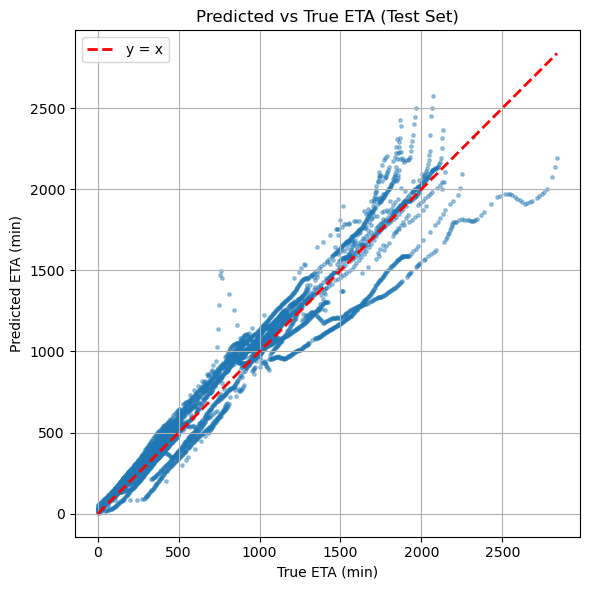

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_test,
    s=6,
    alpha=0.4
)

# y = x reference line
min_eta = min(y_test.min(), y_pred_test.min())
max_eta = max(y_test.max(), y_pred_test.max())

plt.plot(
    [min_eta, max_eta],
    [min_eta, max_eta],
    'r--',
    linewidth=2,
    label="y = x"
)

plt.xlabel("True ETA (min)")
plt.ylabel("Predicted ETA (min)")
plt.title("Predicted vs True ETA (Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
